In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

In [3]:
df_original = pd.read_csv(
    "Analisis GAC Full7agosto 2026(Funnel).csv",
    header=None,
    encoding="utf-8-sig",
    dtype=str,
    keep_default_na=False
)

print("Dimensiones originales:", df_original.shape)

df_original.head()

Dimensiones originales: (264, 71)


,0,1,2,3,4,5,6,7,8,9,...,61,62,63,64,65,66,67,68,69,70
0,Funnel Historico por Mes,,,,,,,,,,...,,,,,,,,,,
1,,,,,,,,,,,...,,,,,,,,,,
2,Funnel Enero 2025,,,,,,,,,,...,,,,,,,,,,
3,GAC Angelopolis,,,,,,,Plaza Ange,,,...,,,,,,,,,,
4,Item,Obj,Real,Acumulado,Obj al dia,Cumplimiento,,Item,Obj,Real,...,,,,,,,,,,


In [ ]:
#Estandarizar los textos
def limpiar_texto(valor):

    valor = str(valor)

    # Eliminar acentos
    valor = (
        unicodedata.normalize("NFKD", valor)
        .encode("ascii", "ignore")
        .decode()
    )

    # Convertir a minúsculas
    valor = valor.lower().strip()

    # Eliminar espacios duplicados
    valor = re.sub(r"\s+", " ", valor)

    return valor

In [ ]:
#Definir los meses
meses = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}

In [6]:
#Estandarizar las etapas del funnel
etapas_funnel = {
    "ventas": "Ventas",
    "leads generados": "Leads_generados",
    "leads efectivos": "Leads_efectivos",
    "cita programada": "Citas_programadas",
    "cita efectiva": "Citas_efectivas",
    "prueba de manejo": "Pruebas_manejo",
    "solicitud de credito generada": "Solicitudes_generadas",
    "solicitud de credito aprobada": "Solicitudes_aprobadas",
    "cerrador": "Formalizados",
    "formalizado": "Formalizados"
}

In [7]:
#Identificar bloques mensuales
bloques_mensuales = []

for indice, valor in enumerate(df_original.iloc[:, 0]):

    texto = limpiar_texto(valor)

    coincidencia = re.fullmatch(
        r"funnel ([a-z]+) (20\d{2})",
        texto
    )

    if coincidencia:

        nombre_mes = coincidencia.group(1)
        anio = int(coincidencia.group(2))

        bloques_mensuales.append(
            (indice, nombre_mes, anio)
        )

bloques_mensuales

[(2, 'enero', 2025),
 (16, 'febrero', 2025),
 (30, 'marzo', 2025),
 (44, 'abril', 2025),
 (58, 'mayo', 2025),
 (72, 'junio', 2025),
 (86, 'julio', 2025),
 (100, 'agosto', 2025),
 (115, 'septiembre', 2025),
 (130, 'octubre', 2025),
 (145, 'noviembre', 2025),
 (160, 'diciembre', 2025),
 (175, 'enero', 2026),
 (190, 'febrero', 2026),
 (205, 'marzo', 2026),
 (220, 'abril', 2026),
 (235, 'mayo', 2026),
 (250, 'junio', 2026)]

In [8]:
#Extraer los valores reales de cada mes
registros = []

for posicion, bloque in enumerate(bloques_mensuales):

    fila_inicio, nombre_mes, anio = bloque

    # La última fila del bloque será el inicio del siguiente mes
    if posicion + 1 < len(bloques_mensuales):
        fila_final = bloques_mensuales[posicion + 1][0]
    else:
        fila_final = len(df_original)

    # Crear el registro mensual
    registro = {
        "Fecha": pd.Timestamp(
            year=anio,
            month=meses[nombre_mes],
            day=1
        ),
        "Mes": nombre_mes.title(),
        "Anio": anio
    }

    # Recorrer las filas del bloque mensual
    for fila in range(fila_inicio + 1, fila_final):

        item = limpiar_texto(
            df_original.iloc[fila, 0]
        )

        nombre_variable = etapas_funnel.get(item)

        if nombre_variable is not None:

            # La columna 2 contiene el valor Real
            valor_real = str(
                df_original.iloc[fila, 2]
            )

            # Eliminar comas y espacios
            valor_real = (
                valor_real
                .replace(",", "")
                .strip()
            )

            # Convertir a número
            valor_real = pd.to_numeric(
                valor_real,
                errors="coerce"
            )

            registro[nombre_variable] = valor_real

    registros.append(registro)

In [9]:
#Crear el Dataframe limpio
df = pd.DataFrame(registros)

orden_columnas = [
    "Fecha",
    "Mes",
    "Anio",
    "Leads_generados",
    "Leads_efectivos",
    "Citas_programadas",
    "Citas_efectivas",
    "Pruebas_manejo",
    "Solicitudes_generadas",
    "Solicitudes_aprobadas",
    "Formalizados",
    "Ventas"
]

df = df.reindex(columns=orden_columnas)

df

,Fecha,Mes,Anio,Leads_generados,Leads_efectivos,Citas_programadas,Citas_efectivas,Pruebas_manejo,Solicitudes_generadas,Solicitudes_aprobadas,Formalizados,Ventas
0,2025-01-01,Enero,2025,1029,710,189,109,86,82,29,19,26
1,2025-02-01,Febrero,2025,537,446,117,101,97,75,27,11,20
2,2025-03-01,Marzo,2025,925,731,181,140,77,92,30,18,30
3,2025-04-01,Abril,2025,1149,873,174,114,81,59,35,17,30
4,2025-05-01,Mayo,2025,815,689,166,157,121,76,40,19,34
5,2025-06-01,Junio,2025,1083,694,226,177,111,97,46,25,40
6,2025-07-01,Julio,2025,1358,893,256,193,127,104,41,21,36
7,2025-08-01,Agosto,2025,1419,624,300,194,123,99,27,13,27
8,2025-09-01,Septiembre,2025,1100,660,273,212,116,127,43,25,38
9,2025-10-01,Octubre,2025,1192,695,304,220,154,136,51,25,40


In [10]:
#Convertir las variables a formato numerico
columnas_numericas = [
    "Leads_generados",
    "Leads_efectivos",
    "Citas_programadas",
    "Citas_efectivas",
    "Pruebas_manejo",
    "Solicitudes_generadas",
    "Solicitudes_aprobadas",
    "Formalizados",
    "Ventas"
]

for columna in columnas_numericas:

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

In [11]:
#Ordenar los meses
df.sort_values(
    by="Fecha",
    inplace=True
)

df.reset_index(
    drop=True,
    inplace=True
)

df

,Fecha,Mes,Anio,Leads_generados,Leads_efectivos,Citas_programadas,Citas_efectivas,Pruebas_manejo,Solicitudes_generadas,Solicitudes_aprobadas,Formalizados,Ventas
0,2025-01-01,Enero,2025,1029,710,189,109,86,82,29,19,26
1,2025-02-01,Febrero,2025,537,446,117,101,97,75,27,11,20
2,2025-03-01,Marzo,2025,925,731,181,140,77,92,30,18,30
3,2025-04-01,Abril,2025,1149,873,174,114,81,59,35,17,30
4,2025-05-01,Mayo,2025,815,689,166,157,121,76,40,19,34
5,2025-06-01,Junio,2025,1083,694,226,177,111,97,46,25,40
6,2025-07-01,Julio,2025,1358,893,256,193,127,104,41,21,36
7,2025-08-01,Agosto,2025,1419,624,300,194,123,99,27,13,27
8,2025-09-01,Septiembre,2025,1100,660,273,212,116,127,43,25,38
9,2025-10-01,Octubre,2025,1192,695,304,220,154,136,51,25,40


In [12]:
#Revisar nulos
print("Valores faltantes por columna:")

print(df.isna().sum())

Valores faltantes por columna:
Fecha                    0
Mes                      0
Anio                     0
Leads_generados          0
Leads_efectivos          0
Citas_programadas        0
Citas_efectivas          0
Pruebas_manejo           0
Solicitudes_generadas    0
Solicitudes_aprobadas    0
Formalizados             0
Ventas                   0
dtype: int64


In [13]:
#Revisar duplicados exactos
print("Filas duplicadas:")
print(df.duplicated().sum())

Filas duplicadas:
0


In [14]:
#Revisar valores negativos
for columna in columnas_numericas:

    cantidad_negativos = (
        df[columna] < 0
    ).sum()

    print(
        columna,
        "- valores negativos:",
        cantidad_negativos
    )

Leads_generados - valores negativos: 0
Leads_efectivos - valores negativos: 0
Citas_programadas - valores negativos: 0
Citas_efectivas - valores negativos: 0
Pruebas_manejo - valores negativos: 0
Solicitudes_generadas - valores negativos: 0
Solicitudes_aprobadas - valores negativos: 0
Formalizados - valores negativos: 0
Ventas - valores negativos: 0


In [15]:
#Verificar base limpia
print("Dimensiones finales:", df.shape)

df.info()

Dimensiones finales: (18, 12)
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Fecha                  18 non-null     datetime64[us]
 1   Mes                    18 non-null     str           
 2   Anio                   18 non-null     int64         
 3   Leads_generados        18 non-null     int64         
 4   Leads_efectivos        18 non-null     int64         
 5   Citas_programadas      18 non-null     int64         
 6   Citas_efectivas        18 non-null     int64         
 7   Pruebas_manejo         18 non-null     int64         
 8   Solicitudes_generadas  18 non-null     int64         
 9   Solicitudes_aprobadas  18 non-null     int64         
 10  Formalizados           18 non-null     int64         
 11  Ventas                 18 non-null     int64         
dtypes: datetime64[us](1), int64(10), str(1)
memory 

Regresion lineal



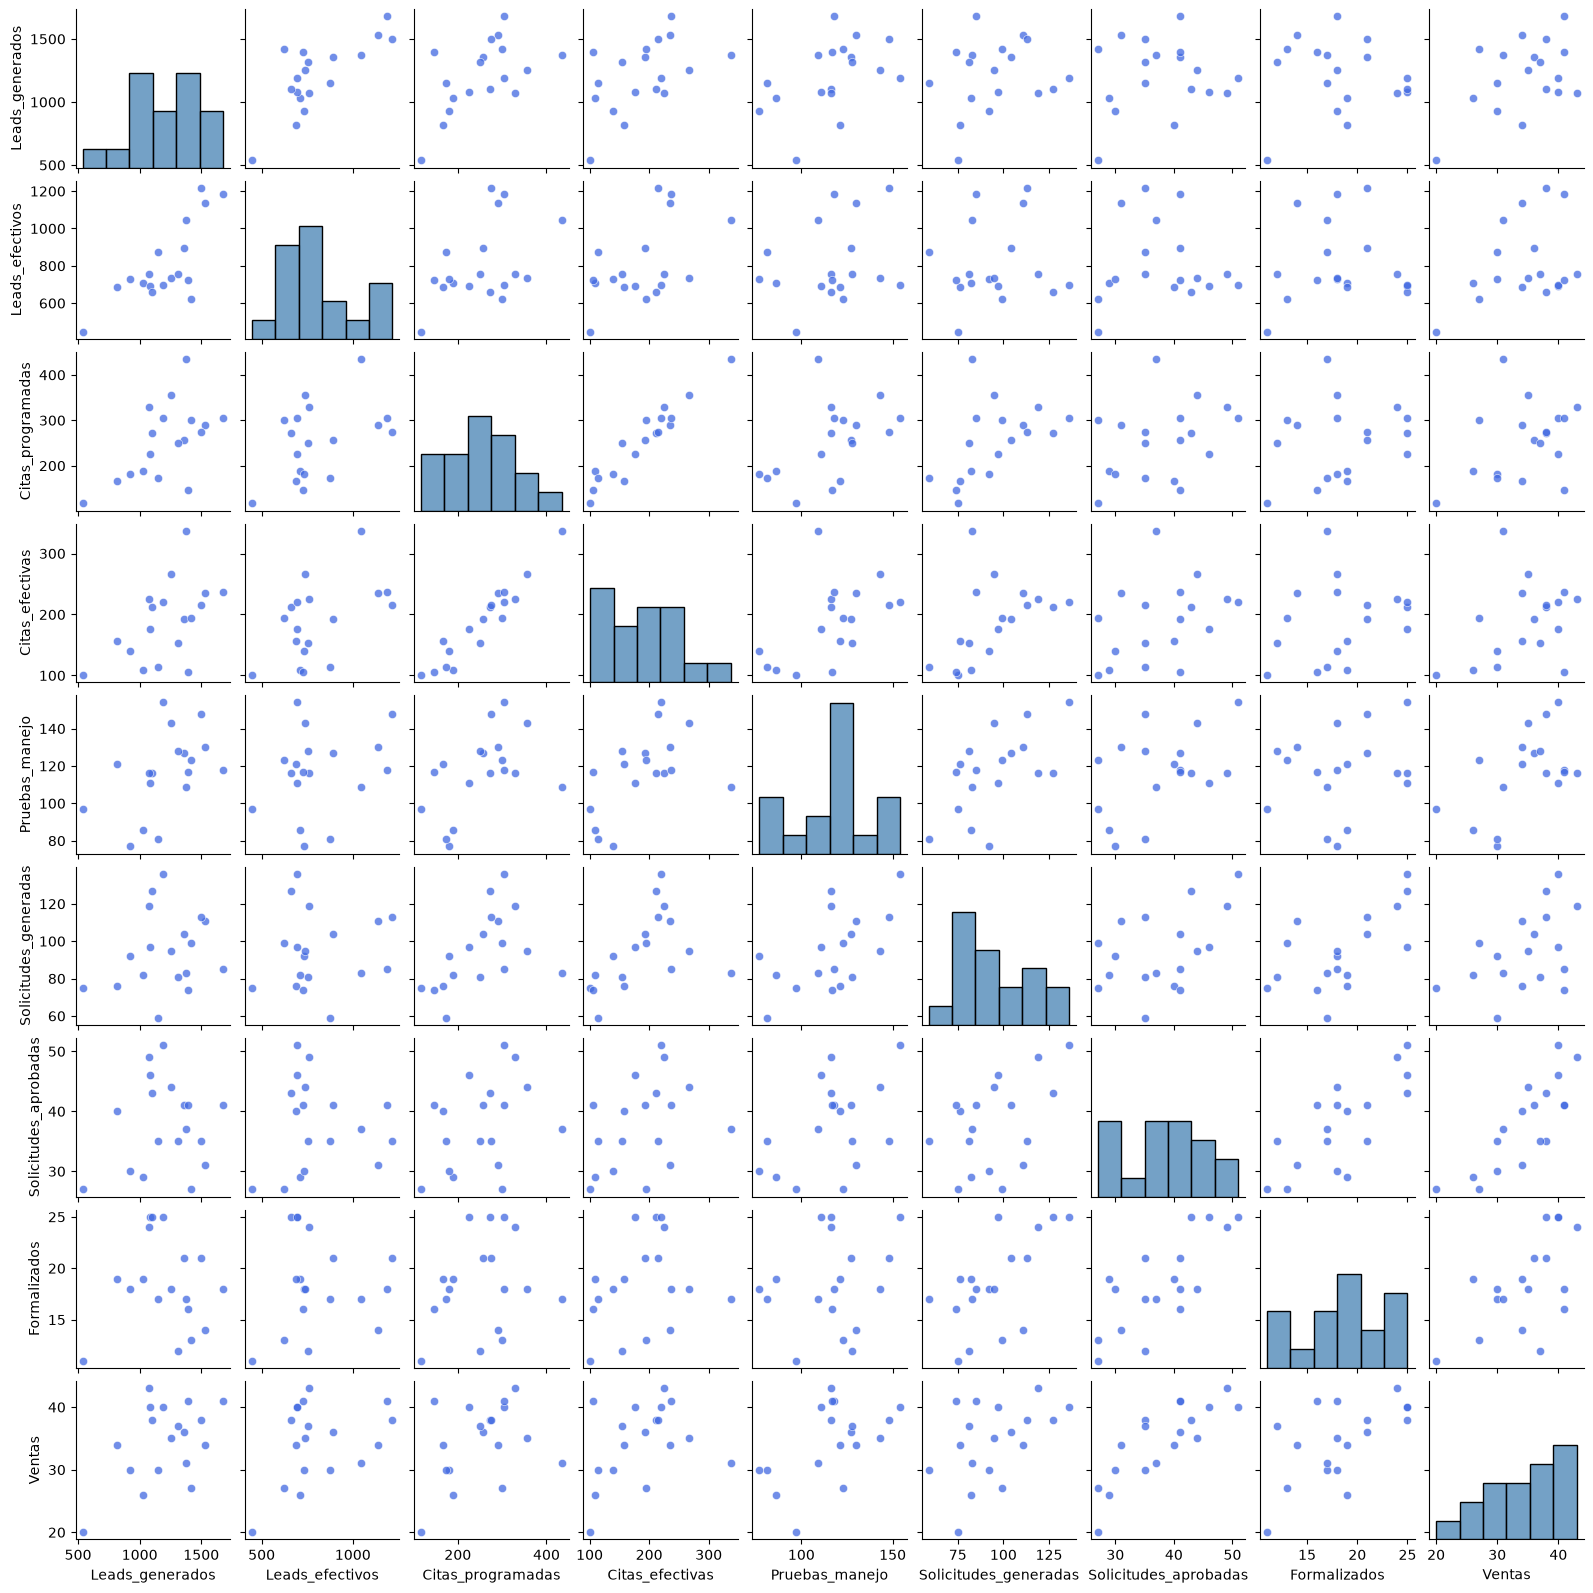

In [16]:
df_pairplot = df[columnas_numericas].copy()

sns.pairplot(
    df_pairplot,
    diag_kind="hist",
    height=1.8,
    plot_kws={
        "color": "royalblue",
        "s": 35,
        "alpha": 0.75
    },
    diag_kws={
        "color": "steelblue",
        "edgecolor": "black"
    }
)

plt.show()

In [17]:
Corr_Factors = df[columnas_numericas].corr()

Corr_Factors

,Leads_generados,Leads_efectivos,Citas_programadas,Citas_efectivas,Pruebas_manejo,Solicitudes_generadas,Solicitudes_aprobadas,Formalizados,Ventas
Leads_generados,1.000000,0.762464,0.569892,0.513392,0.479943,0.198869,0.119646,-0.026844,0.486712
Leads_efectivos,0.762464,1.000000,0.460505,0.520114,0.261287,0.088391,0.019077,0.041681,0.351173
Citas_programadas,0.569892,0.460505,1.000000,0.955216,0.496667,0.479842,0.349805,0.224749,0.335212
Citas_efectivas,0.513392,0.520114,0.955216,1.000000,0.518758,0.473843,0.374067,0.255077,0.342661
Pruebas_manejo,0.479943,0.261287,0.496667,0.518758,1.000000,0.592393,0.474863,0.210419,0.535350
Solicitudes_generadas,0.198869,0.088391,0.479842,0.473843,0.592393,1.000000,0.465714,0.620486,0.460497
Solicitudes_aprobadas,0.119646,0.019077,0.349805,0.374067,0.474863,0.465714,1.000000,0.762295,0.822709
Formalizados,-0.026844,0.041681,0.224749,0.255077,0.210419,0.620486,0.762295,1.000000,0.606540
Ventas,0.486712,0.351173,0.335212,0.342661,0.535350,0.460497,0.822709,0.606540,1.000000


In [18]:
Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Leads_generados,Leads_efectivos,Citas_programadas,Citas_efectivas,Pruebas_manejo,Solicitudes_generadas,Solicitudes_aprobadas,Formalizados,Ventas
Leads_generados,1.000000,0.762464,0.569892,0.513392,0.479943,0.198869,0.119646,0.026844,0.486712
Leads_efectivos,0.762464,1.000000,0.460505,0.520114,0.261287,0.088391,0.019077,0.041681,0.351173
Citas_programadas,0.569892,0.460505,1.000000,0.955216,0.496667,0.479842,0.349805,0.224749,0.335212
Citas_efectivas,0.513392,0.520114,0.955216,1.000000,0.518758,0.473843,0.374067,0.255077,0.342661
Pruebas_manejo,0.479943,0.261287,0.496667,0.518758,1.000000,0.592393,0.474863,0.210419,0.535350
Solicitudes_generadas,0.198869,0.088391,0.479842,0.473843,0.592393,1.000000,0.465714,0.620486,0.460497
Solicitudes_aprobadas,0.119646,0.019077,0.349805,0.374067,0.474863,0.465714,1.000000,0.762295,0.822709
Formalizados,0.026844,0.041681,0.224749,0.255077,0.210419,0.620486,0.762295,1.000000,0.606540
Ventas,0.486712,0.351173,0.335212,0.342661,0.535350,0.460497,0.822709,0.606540,1.000000


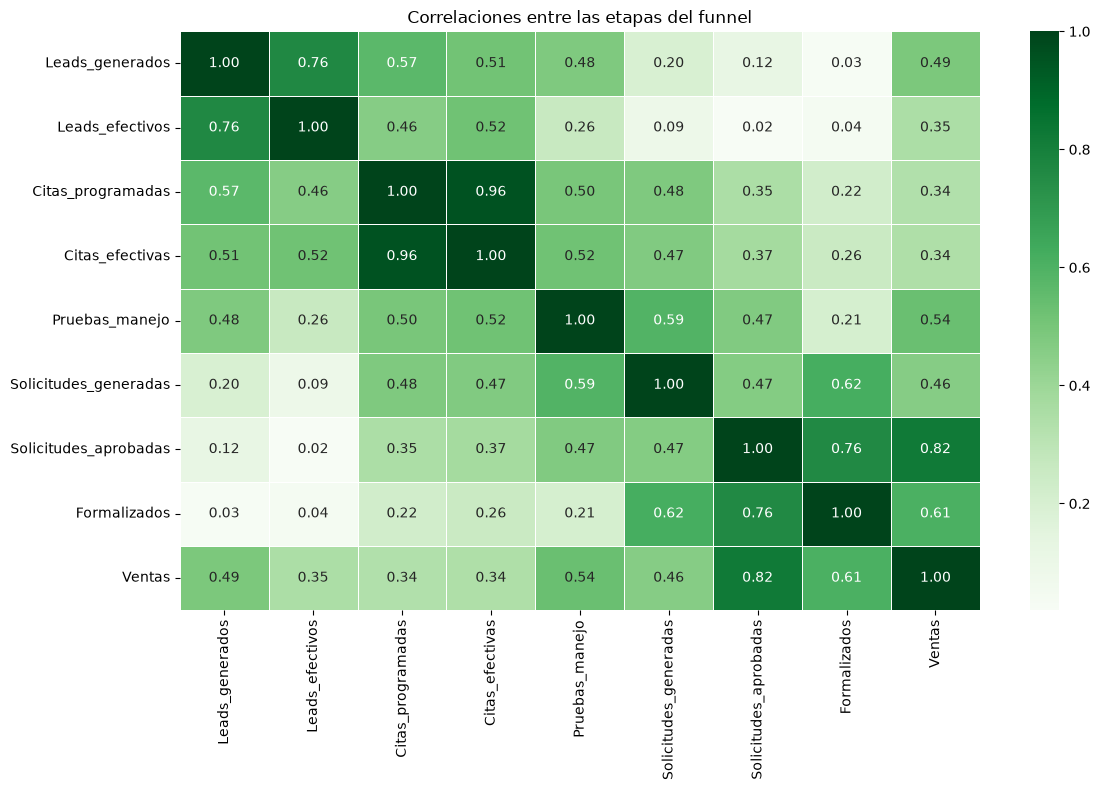

In [19]:
plt.figure(figsize=(12, 8))

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap="Greens",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlaciones entre las etapas del funnel"
)

plt.tight_layout()
plt.show()

In [21]:
df_regresion = df[
    ["Leads_generados", "Ventas"]
].dropna().copy()

df_regresion.reset_index(
    drop=True,
    inplace=True
)

df_regresion

,Leads_generados,Ventas
0,1029,26
1,537,20
2,925,30
3,1149,30
4,815,34
5,1083,40
6,1358,36
7,1419,27
8,1100,38
9,1192,40


In [22]:
# Variable independiente X
Vars_Indep = df_regresion[
    ["Leads_generados"]
]

# Variable dependiente Y
Var_Dep = df_regresion["Ventas"]

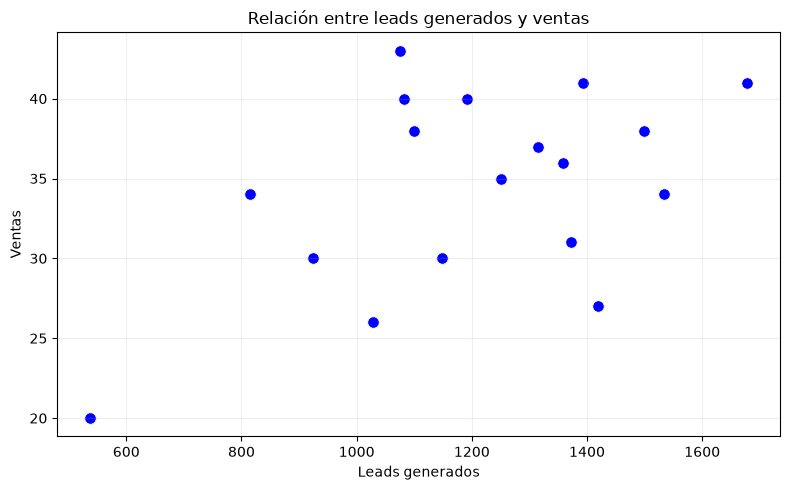

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Leads_generados",
    y="Ventas",
    data=df_regresion,
    color="blue",
    s=70
)

plt.title(
    "Relación entre leads generados y ventas"
)

plt.xlabel("Leads generados")
plt.ylabel("Ventas")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression

# Crear el modelo
model = LinearRegression()

# Ajustar el modelo
model.fit(
    X=Vars_Indep,
    y=Var_Dep
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Leads_generados']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,21.54
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [25]:
print("Intercepto:", model.intercept_)
print("Coeficiente:", model.coef_[0])

Intercepto: 21.535654243331848
Coeficiente: 0.010741460235674419


In [26]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Leads_generados'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.01074146]),
 'rank_': np.int64(1),
 'singular_': array([1148.53861252]),
 'intercept_': np.float64(21.535654243331848)}

In [27]:
y_pred = model.predict(
    Vars_Indep
)

y_pred

array([32.58861683, 27.30381839, 31.47150496, 33.87759205, 30.28994434,
       33.16865568, 36.12255724, 36.77778632, 33.3512605 , 34.33947484,
       33.082724  , 38.01305424, 37.63710314, 36.28367915, 39.55982452,
       36.49850835, 34.973221  , 35.66067445])

In [28]:
df_regresion["Predicciones"] = y_pred

df_regresion

,Leads_generados,Ventas,Predicciones
0,1029,26,32.588617
1,537,20,27.303818
2,925,30,31.471505
3,1149,30,33.877592
4,815,34,30.289944
5,1083,40,33.168656
6,1358,36,36.122557
7,1419,27,36.777786
8,1100,38,33.351261
9,1192,40,34.339475


In [29]:
df_regresion_ordenado = df_regresion.sort_values(
    by="Leads_generados"
)

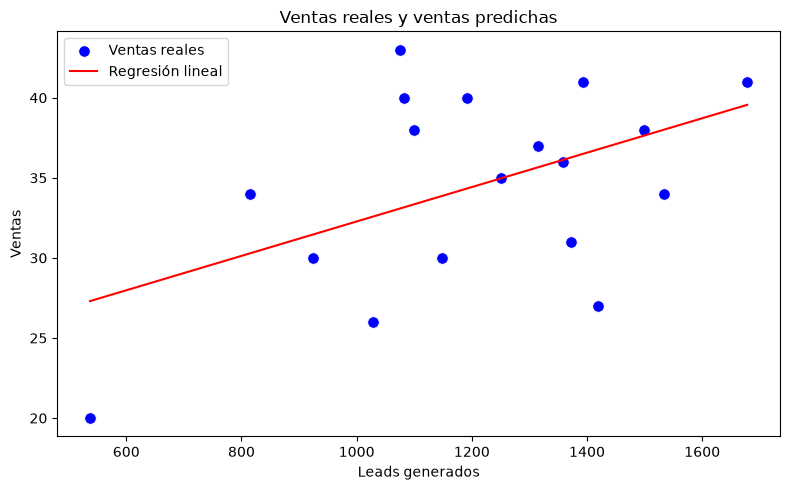

In [30]:
plt.figure(figsize=(8, 5))

# Ventas reales
sns.scatterplot(
    x="Leads_generados",
    y="Ventas",
    data=df_regresion,
    color="blue",
    s=70,
    label="Ventas reales"
)

# Valores predichos
sns.lineplot(
    x="Leads_generados",
    y="Predicciones",
    data=df_regresion_ordenado,
    color="red",
    label="Regresión lineal"
)

plt.title(
    "Ventas reales y ventas predichas"
)

plt.xlabel("Leads generados")
plt.ylabel("Ventas")

plt.tight_layout()
plt.show()

In [31]:
coef_Deter = model.score(
    Vars_Indep,
    Var_Dep
)

print("R cuadrada:", coef_Deter)

R cuadrada: 0.2368889039834845


In [32]:
coef_Correl = df_regresion[
    "Leads_generados"
].corr(
    df_regresion["Ventas"]
)

print("Coeficiente de correlación:", coef_Correl)

Coeficiente de correlación: 0.4867123421318637
